```python

import requests
import pandas as pd
from datetime import datetime, timedelta

API_KEY = "d958a4f3912d79ee77d2dc0a39ee2a17"

start_date = datetime(2025, 1, 1)
end_date = datetime(2025, 12, 31)

rows = []

current = start_date

while current <= end_date:

    target_dt = current.strftime("%Y%m%d")

    url = (
        "http://www.kobis.or.kr/kobisopenapi/webservice/rest/"
        f"boxoffice/searchDailyBoxOfficeList.json"
        f"?key={API_KEY}&targetDt={target_dt}"
    )

    result = requests.get(url).json()

    boxoffice = result['boxOfficeResult']['dailyBoxOfficeList']

    for movie in boxoffice:

        rows.append({
            '날짜': target_dt,
            '순위': movie['rank'],
            '영화명': movie['movieNm'],
            '개봉일': movie['openDt'],
            '일일관객수': movie['audiCnt'],
            '누적관객수': movie['audiAcc'],
            '일일매출액': movie['salesAmt']
        })

    current += timedelta(days=1)

df = pd.DataFrame(rows)

print(df.head())

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   날짜      3650 non-null   object
 1   순위      3650 non-null   object
 2   영화명     3650 non-null   object
 3   개봉일     3650 non-null   object
 4   일일관객수   3650 non-null   object
 5   누적관객수   3650 non-null   object
 6   일일매출액   3650 non-null   object
dtypes: object(7)
memory usage: 199.7+ KB


In [10]:
df.head()

,날짜,순위,영화명,개봉일,일일관객수,누적관객수,일일매출액
0,20250101,1,하얼빈,2024-12-24,340484,3095720,3290065760
1,20250101,2,보고타: 마지막 기회의 땅,2024-12-31,93154,194095,880276910
2,20250101,3,소방관,2024-12-04,80830,3398126,769063260
3,20250101,4,수퍼 소닉3,2025-01-01,75916,97373,705207940
4,20250101,5,뽀로로 극장판 바닷속 대모험,2025-01-01,58882,92837,512345060


In [19]:
# df 객체를 파일로 저장
df.to_csv('data/kobis.csv', encoding = 'utf-8', index = False)

- 월별 박스오피스 1등 리스트업

In [29]:
df.dtypes

# 년, 월, 일, 요일 컬럼 생성
df['날짜'] = pd.to_datetime(df['날짜'])
df['연도'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month
df['일'] = df['날짜'].dt.day
df['요일'] = df['날짜'].dt.weekday
df.head()

,날짜,순위,영화명,개봉일,일일관객수,누적관객수,일일매출액,연도,월,일,요일
0,2025-01-01,1,하얼빈,2024-12-24,340484,3095720,3290065760,2025,1,1,2
1,2025-01-01,2,보고타: 마지막 기회의 땅,2024-12-31,93154,194095,880276910,2025,1,1,2
2,2025-01-01,3,소방관,2024-12-04,80830,3398126,769063260,2025,1,1,2
3,2025-01-01,4,수퍼 소닉3,2025-01-01,75916,97373,705207940,2025,1,1,2
4,2025-01-01,5,뽀로로 극장판 바닷속 대모험,2025-01-01,58882,92837,512345060,2025,1,1,2


In [30]:
# 요일(숫자) -> 한글 매핑
week_dict = {
    0 : '월',
    1 : '화',
    2 : '수',
    3 : '목',
    4 : '금',
    5 : '토',
    6 : '일'
}

df['요일'] = df['날짜'].dt.weekday.map(week_dict)
df

,날짜,순위,영화명,개봉일,일일관객수,누적관객수,일일매출액,연도,월,일,요일
0,2025-01-01,1,하얼빈,2024-12-24,340484,3095720,3290065760,2025,1,1,수
1,2025-01-01,2,보고타: 마지막 기회의 땅,2024-12-31,93154,194095,880276910,2025,1,1,수
2,2025-01-01,3,소방관,2024-12-04,80830,3398126,769063260,2025,1,1,수
3,2025-01-01,4,수퍼 소닉3,2025-01-01,75916,97373,705207940,2025,1,1,수
4,2025-01-01,5,뽀로로 극장판 바닷속 대모험,2025-01-01,58882,92837,512345060,2025,1,1,수
...,...,...,...,...,...,...,...,...,...,...,...
3645,2025-12-31,6,극장판 짱구는 못말려: 초화려! 작열하는 떡잎마을 댄서즈,2025-12-24,18979,327390,154747310,2025,12,31,수
3646,2025-12-31,7,화양연화 특별판,2025-12-31,9292,11279,80027452,2025,12,31,수
3647,2025-12-31,8,뽀로로 극장판 스위트캐슬 대모험,2025-12-11,4807,216003,41105520,2025,12,31,수
3648,2025-12-31,9,누벨바그,2025-12-31,4051,4597,24782960,2025,12,31,수


In [53]:
df[df['순위'] == '1']['영화명'].value_counts().head(10)

# 2025년 기준 Top of Top 10
df['누적관객수'] = pd.to_numeric(df['누적관객수'])
df.groupby('영화명')['누적관객수'].max().sort_values(ascending = False).head(10)

df['일일관객수'] = pd.to_numeric(df['일일관객수'])
df.groupby('영화명')['일일관객수'].sum().sort_values(ascending = False).head(10)

영화명
주토피아 2              7703922
극장판 귀멸의 칼날: 무한성편    5650903
좀비딸                 5605086
F1 더 무비             5176850
아바타: 불과 재           4568158
극장판 체인소 맨: 레제편      3406687
미션 임파서블: 파이널 레코닝    3380126
야당                  3370527
미키 17               2996149
어쩔수가없다              2925337
Name: 일일관객수, dtype: int64

In [55]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'

- 월 별 총 매출액 기준 Top10

<Axes: xlabel='월', ylabel='총 매출액'>

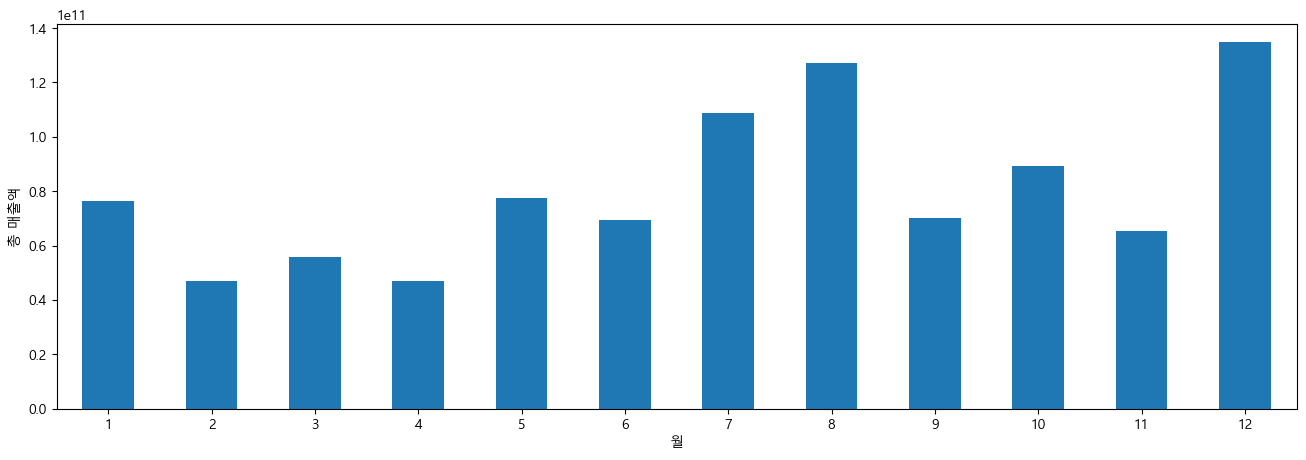

In [61]:
df['일일매출액'] = pd.to_numeric(df['일일매출액'])
result = df.groupby('월')['일일매출액'].sum()
result.plot(
    kind = 'bar',
    figsize = (16, 5),
    rot = 0,
    ylabel = '총 매출액'
)

- 요일별 일일 관객 수 추이

요일
월     8318811
화     7951556
수    12657300
목    10303793
금    13034054
토    24433622
일    21394197
Name: 일일관객수, dtype: int64

<Axes: xlabel='요일', ylabel='일일 관객수 합'>

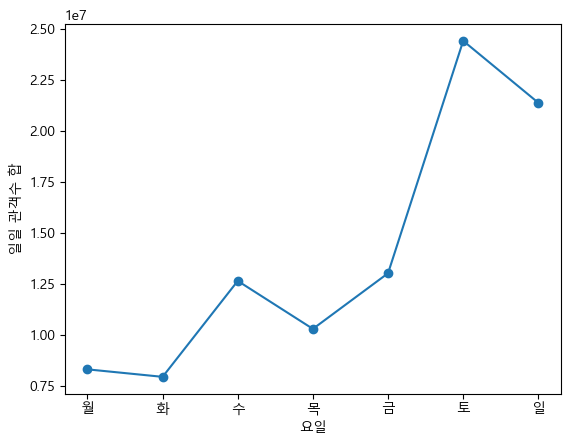

In [69]:
order = ['월', '화', '수', '목', '금', '토', '일']
result2 = df.groupby('요일')['일일관객수'].sum().reindex(order)
display(result2)

result2.plot(
    kind = 'line',
    marker = 'o',
    rot = 0,
    ylabel = '일일 관객수 합'
)